In [1]:
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from src.terramesh import build_terramesh_dataset, Transpose, MultimodalTransforms
from src.plotting_utils import plot_s2, plot_dem, plot_lulc

INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.10). Upgrade using: pip install --upgrade albumentations


In [2]:
# Define all image modalities
modalities = ["S2L2A", "S2L1C", "S2RGB", "S1GRD", "S1RTC", "DEM", "NDVI", "LULC"]
LOCAL_TERRAMESH_PATH = "/dss/dsstbyfs02/pn49cu/pn49cu-dss-0020/terramesh_val/data/TerraMesh/"

# Define multimodal transform function that converts the data into the expected shape from albumentations 
val_transform = MultimodalTransforms(
    transforms=A.Compose([  # We use albumentations because of the shared transform between image modalities
        Transpose([1, 2, 0]),  # Convert data to channel last (expected shape from albumentations)
        A.CenterCrop(224, 224),  # Use center crop in val split
        ToTensorV2(),  # Convert to tensor and back to channel first
    ],
        is_check_shapes=False,  # Not needed because of aligned data in TerraMesh
        additional_targets={m: "image" for m in modalities},  # Only image keys
    ),
    #non_image_modalities=["__key__", "__url__"],  # Additional non-image keys
    non_image_modalities=["__key__", "__url__", "center_lon", "center_lat", "cloud_mask"] + ["time_" + m for m in modalities]
)

dataset = build_terramesh_dataset(
    path=LOCAL_TERRAMESH_PATH,
    modalities=modalities,
    split="val",
    shuffle=False,
    transform=val_transform,
    batch_size=1,
    return_metadata=True,
)

# Set batch size to None because batching is handled by WebDataset.
dataloader = DataLoader(dataset, batch_size=None, num_workers=32, persistent_workers=True, prefetch_factor=1)


In [3]:
def check_spatial_shapes(sample: dict) -> None:
    """Raise AssertionError if any image modality differs in height/width."""
    # pick the first image modality (skip non‑image keys) → reference spatial size
    ref_mod = next(k for k in sample.keys()
                   if k not in ["__key__", "__url__", "center_lon", "center_lat", "cloud_mask"] + ["time_" + m for m in modalities])
    print(sample[ref_mod].shape )
    _, _, ref_h, ref_w = sample[ref_mod].shape   # (B, C, H, W)

    for mod, data in sample.items():
        if mod in ['S2L2A', 'S2L1C', 'S2RGB', 'S1RTC', 'DEM', 'NDVI']:
            _, _, h, w = data.shape
            assert (h, w) == (ref_h, ref_w), (
                f"Spatial shape mismatch: {mod} ({h}×{w}) vs reference "
                f"{ref_mod} ({ref_h}×{ref_w})"
            )

Batch keys: ['__key__', '__url__', 'center_lon', 'center_lat', 'cloud_mask', 'time_S2L2A', 'time_S2L1C', 'time_S2RGB', 'time_S1RTC', 'time_NDVI', 'time_LULC', 'S2L2A', 'S2L1C', 'S2RGB', 'S1RTC', 'DEM', 'NDVI', 'LULC']
torch.Size([1, 12, 224, 224])
Image modalities & shapes:
   - S2L2A: torch.Size([1, 12, 224, 224])
   - S2L1C: torch.Size([1, 13, 224, 224])
   - S2RGB: torch.Size([1, 3, 224, 224])
   - S1RTC: torch.Size([1, 2, 224, 224])
   - DEM: torch.Size([1, 1, 224, 224])
   - NDVI: torch.Size([1, 1, 224, 224])
   - LULC: torch.Size([1, 1, 224, 224])
tensor([103.3161], dtype=torch.float64)


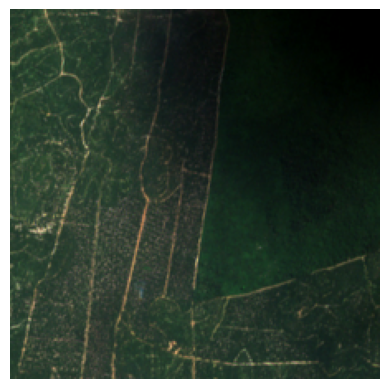

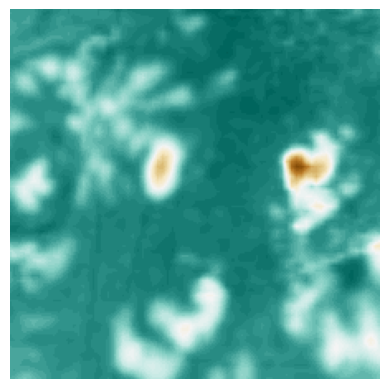

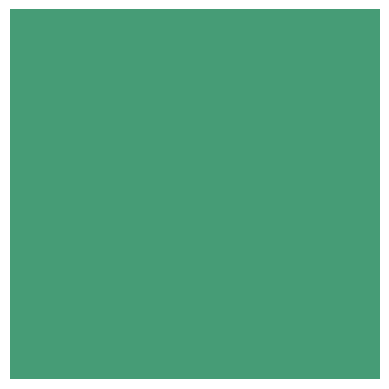

In [4]:
# Iterate over the dataloader
for batch in dataloader:
    print("Batch keys:", list(batch.keys()))
    # Batch keys: ["__key__", "__url__", "S2L2A", "S2L1C", "S2RGB", "S1RTC", "DEM", "NDVI", "LULC"]
    # Because S1RTC and S1GRD are not present for all samples, each batch only includes one S1 version.

    check_spatial_shapes(batch)

    print("Image modalities & shapes:")
    for mod in modalities:
        if mod in batch:
            print(f"   - {mod}: {batch[mod].shape}")

    print(batch["center_lon"])

    plot_s2(batch["S2L2A"])
    plot_dem(batch["DEM"])
    plot_lulc(batch["LULC"])

    break